In [1]:
# Step 1: Load the dataset
from ucimlrepo import fetch_ucirepo
import pandas as pd

concrete_data = fetch_ucirepo(id=165)

X = concrete_data.data.features
y = concrete_data.data.targets

df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Shape: (1030, 9)

Columns: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Concrete compressive strength']

First 5 rows:


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [2]:
# Step 2: Data Understanding & Cleaning

# 1. Basic info — data types, non-null counts
print("=== INFO ===")
df.info()

# 2. Missing values check
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# 3. Duplicate rows check
print("\n=== DUPLICATES ===")
print("Number of duplicate rows:", df.duplicated().sum())

# 4. Summary statistics
print("\n=== SUMMARY STATISTICS ===")
df.describe()

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete compressive strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB

=== MISSING VALUES ===
Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer 

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [3]:
# Remove duplicate rows
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", df.shape)

# Confirm no duplicates remain
print("Remaining duplicates:", df.duplicated().sum())

Before removing duplicates: (1030, 9)
After removing duplicates: (1005, 9)
Remaining duplicates: 0


Matplotlib is building the font cache; this may take a moment.


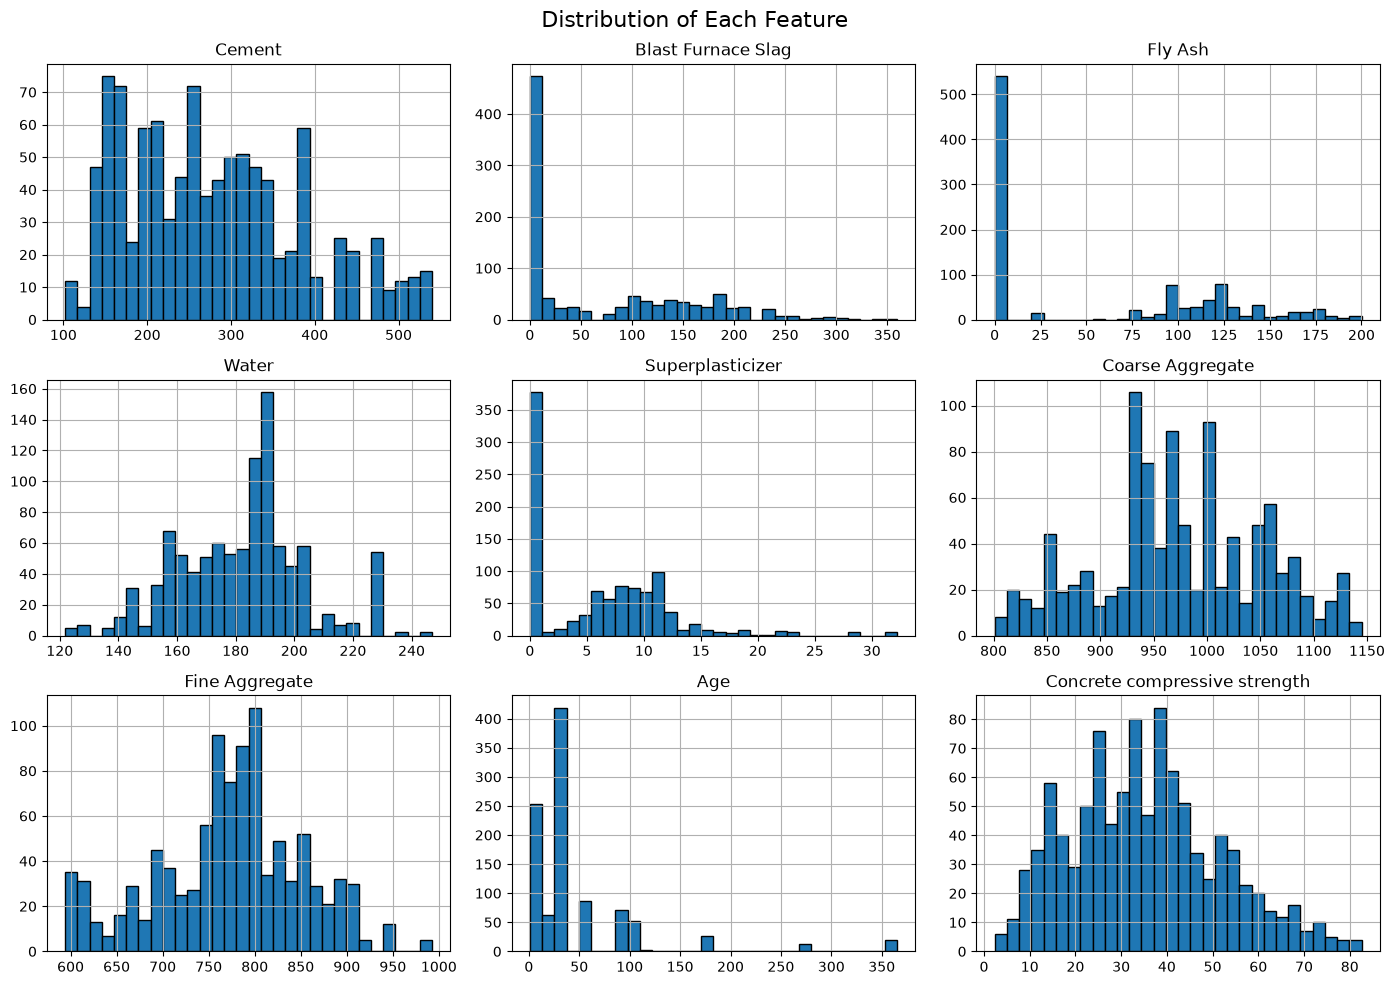

In [4]:
# Step 3: Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution plots for each feature
df.hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle("Distribution of Each Feature", fontsize=16)
plt.tight_layout()
plt.show()

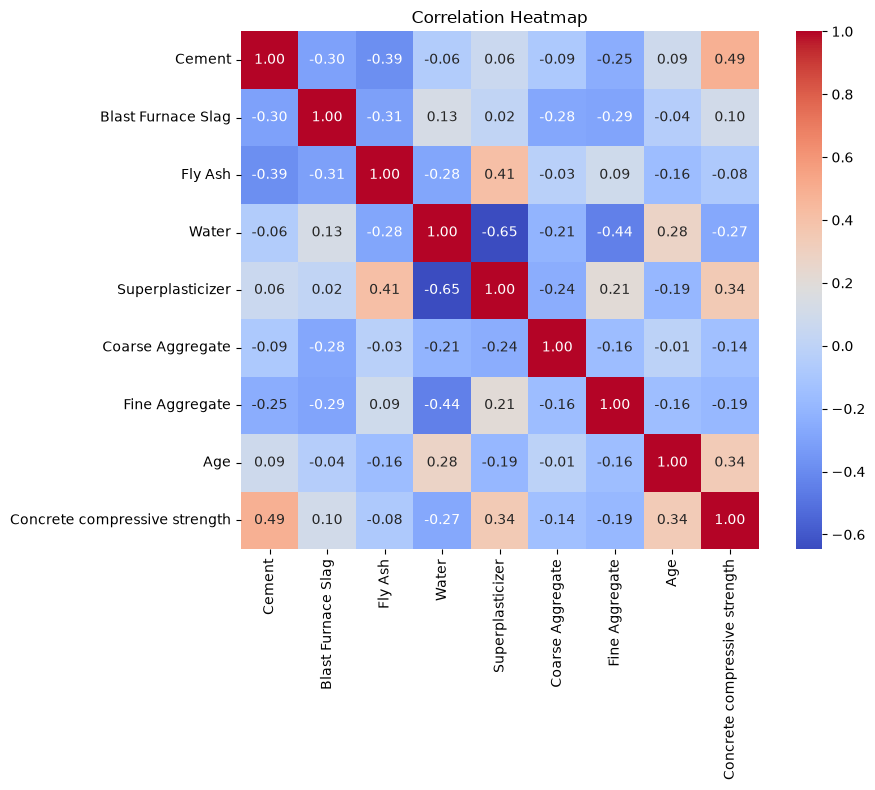

In [5]:
# 2. Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

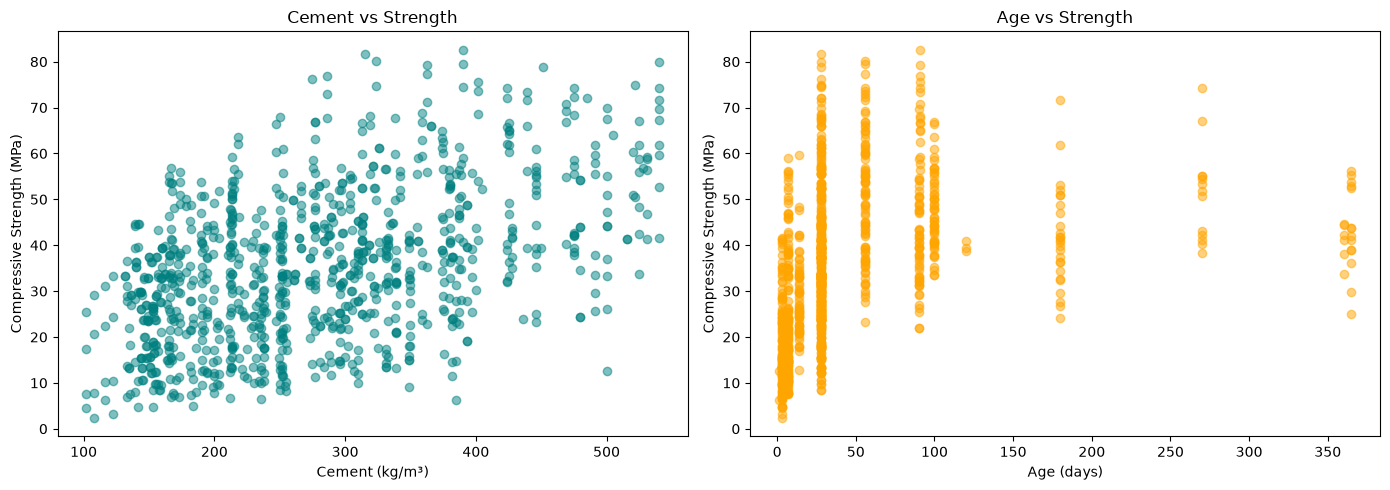

In [7]:
# 3. Scatter plots: key features vs Strength
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Cement'], df['Concrete compressive strength'], alpha=0.5, color='teal')
axes[0].set_xlabel('Cement (kg/m³)')
axes[0].set_ylabel('Compressive Strength (MPa)')
axes[0].set_title('Cement vs Strength')

axes[1].scatter(df['Age'], df['Concrete compressive strength'], alpha=0.5, color='orange')
axes[1].set_xlabel('Age (days)')
axes[1].set_ylabel('Compressive Strength (MPa)')
axes[1].set_title('Age vs Strength')

plt.tight_layout()
plt.show()

In [8]:
# Step 4: Train-Test Split + Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('Concrete compressive strength', axis=1)
y = df['Concrete compressive strength']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling done. Sample scaled values (first row):")
print(X_train_scaled[0])

Train shape: (804, 8)
Test shape: (201, 8)

Scaling done. Sample scaled values (first row):
[ 2.43672824 -0.83765521 -0.87586539 -1.87288113  3.72010571 -1.56005896
  1.48730406 -0.67904126]


In [9]:
# Step 5: Model Building — Linear Regression, Random Forest, XGBoost
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({"Model": name, "R2": round(r2, 4), "RMSE": round(rmse, 4), "MAE": round(mae, 4)})

results_df = pd.DataFrame(results)
print(results_df)

               Model      R2     RMSE     MAE
0  Linear Regression  0.5802  11.1913  8.8953
1      Random Forest  0.9076   5.2496  3.4835
2            XGBoost  0.9243   4.7517  2.9306


              Feature  Importance
7                 Age    0.230231
0              Cement    0.226482
4    Superplasticizer    0.177670
1  Blast Furnace Slag    0.128150
3               Water    0.104414
2             Fly Ash    0.057361
6      Fine Aggregate    0.054847
5    Coarse Aggregate    0.020845


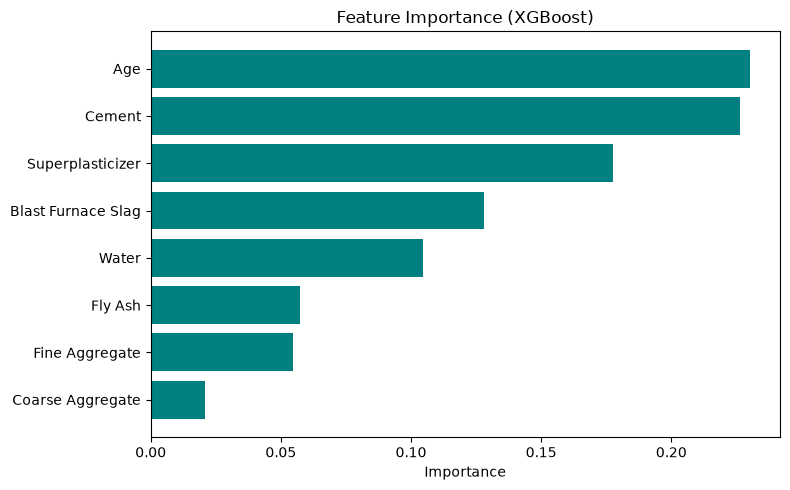

In [11]:
# Step 6: Best Model Selection + Feature Importance
best_model = models["XGBoost"]

importances = best_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color='teal')
plt.xlabel("Importance")
plt.title("Feature Importance (XGBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/concrete_data.csv", index=False)
print("Saved to data/concrete_data.csv")

Saved to data/concrete_data.csv
